In [5]:
from IPython.display import Markdown, display

display(Markdown("""
**Ноутбук 1: 01_EDA_and_baseline.ipynb**

В рамках первого ноутбука был проведён разведочный анализ данных и построены первые baseline-модели. Был загружен обучающий датасет, выявлен сильный дисбаланс целевой переменной TARGET (лишь около 8% дефолтов) и обнаружены 67 признаков с пропусками, часть из которых теряла более 50% значений. 

Аномалия в признаке DAYS_EMPLOYED была интерпретирована как отсутствие данных. 

Корреляционный анализ показал, что наиболее значимые отрицательные корреляции с дефолтом имеют EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 и возраст клиента (DAYS_BIRTH). Категориальный признак NAME_CONTRACT_TYPE также влияет на дефолтность. 

Визуализации распределений подтвердили необходимость логарифмирования сильно скошенных признаков (доходы, суммы кредита). 

В итоге были сделаны балансировка классов, обработка пропусков, удаление аномалий и создание новых признаков.
"""))


**Ноутбук 1: 01_EDA_and_baseline.ipynb**

В рамках первого ноутбука был проведён разведочный анализ данных и построены первые baseline-модели. Был загружен обучающий датасет, выявлен сильный дисбаланс целевой переменной TARGET (лишь около 8% дефолтов) и обнаружены 67 признаков с пропусками, часть из которых теряла более 50% значений. 

Аномалия в признаке DAYS_EMPLOYED была интерпретирована как отсутствие данных. 

Корреляционный анализ показал, что наиболее значимые отрицательные корреляции с дефолтом имеют EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 и возраст клиента (DAYS_BIRTH). Категориальный признак NAME_CONTRACT_TYPE также влияет на дефолтность. 

Визуализации распределений подтвердили необходимость логарифмирования сильно скошенных признаков (доходы, суммы кредита). 

В итоге были сделаны балансировка классов, обработка пропусков, удаление аномалий и создание новых признаков.


Импорт библиотек и настройки визуализации

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

Загрузка данных

In [3]:
DATA_PATH = "../data/raw/application_train.csv"

df = pd.read_csv(DATA_PATH)
print(f"Загружено {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Загружено 307511 строк, 122 столбцов


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Базовая информация о данных

In [4]:
print("Информация о датафрейме\n")
df.info()

Информация о датафрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [5]:
print("\nПервые 5 строк\n")
df.head()


Первые 5 строк



,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print("\nОписательная статистика для числовых признаков\n")
df.describe()



Описательная статистика для числовых признаков



,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


Анализ целевой переменной

In [7]:
target_counts = df['TARGET'].value_counts()
target_percent = df['TARGET'].value_counts(normalize=True)

print("Распределение целевой переменной:")
print(target_counts)
print(f"\nДоля дефолтов: {target_percent[1]:.2%}")

Распределение целевой переменной:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Доля дефолтов: 8.07%


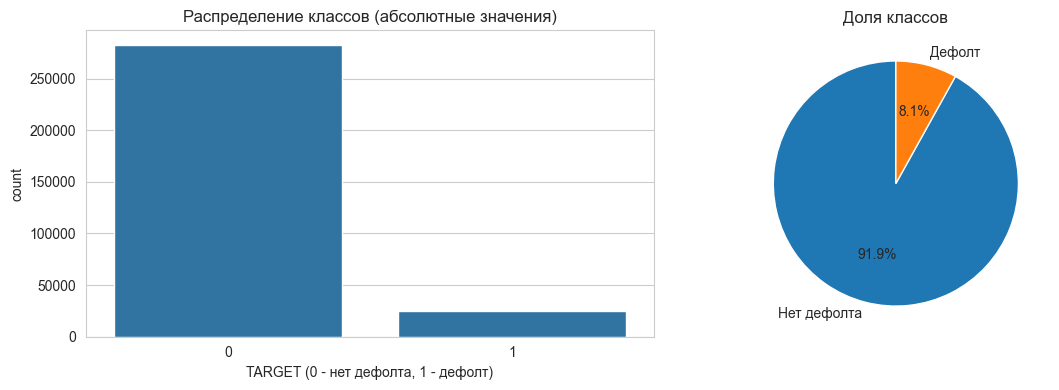

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='TARGET', data=df, ax=ax[0])
ax[0].set_title('Распределение классов (абсолютные значения)')
ax[0].set_xlabel('TARGET (0 - нет дефолта, 1 - дефолт)')

ax[1].pie(target_counts, labels=['Нет дефолта', 'Дефолт'], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Доля классов')

plt.tight_layout()
plt.show()

Вывод: наблюдается сильный дисбаланс (дефолтов мало), т.е. нужно будет учитывать при обучении

Пропуски в данных

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Количество пропусков': missing,
    'Процент пропусков': missing_percent
})
print(f"Всего признаков с пропусками: {len(missing_df)}")
print(missing_df.head(20))

Всего признаков с пропусками: 67
                          Количество пропусков  Процент пропусков
COMMONAREA_MEDI                         214865          69.872297
COMMONAREA_MODE                         214865          69.872297
COMMONAREA_AVG                          214865          69.872297
NONLIVINGAPARTMENTS_MODE                213514          69.432963
NONLIVINGAPARTMENTS_MEDI                213514          69.432963
NONLIVINGAPARTMENTS_AVG                 213514          69.432963
FONDKAPREMONT_MODE                      210295          68.386172
LIVINGAPARTMENTS_AVG                    210199          68.354953
LIVINGAPARTMENTS_MEDI                   210199          68.354953
LIVINGAPARTMENTS_MODE                   210199          68.354953
FLOORSMIN_MEDI                          208642          67.848630
FLOORSMIN_MODE                          208642          67.848630
FLOORSMIN_AVG                           208642          67.848630
YEARS_BUILD_MODE                        204

<Figure size 1000x600 with 0 Axes>

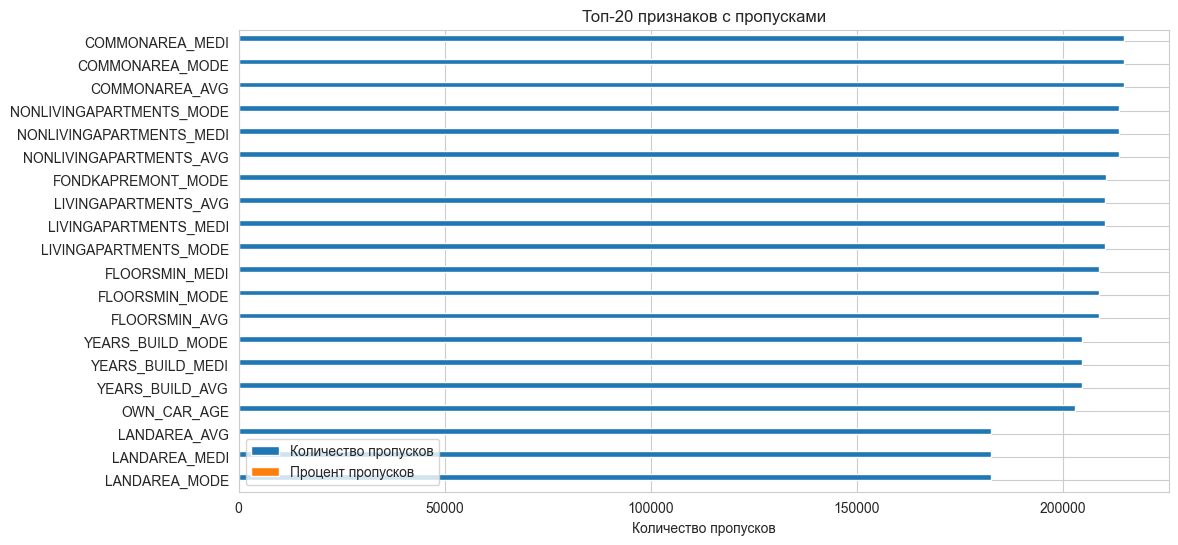

In [10]:
plt.figure(figsize=(10, 6))
missing_df.head(20).plot(kind='barh')
plt.xlabel('Количество пропусков')
plt.title('Топ-20 признаков с пропусками')
plt.gca().invert_yaxis()
plt.show()

Анализ выбросов

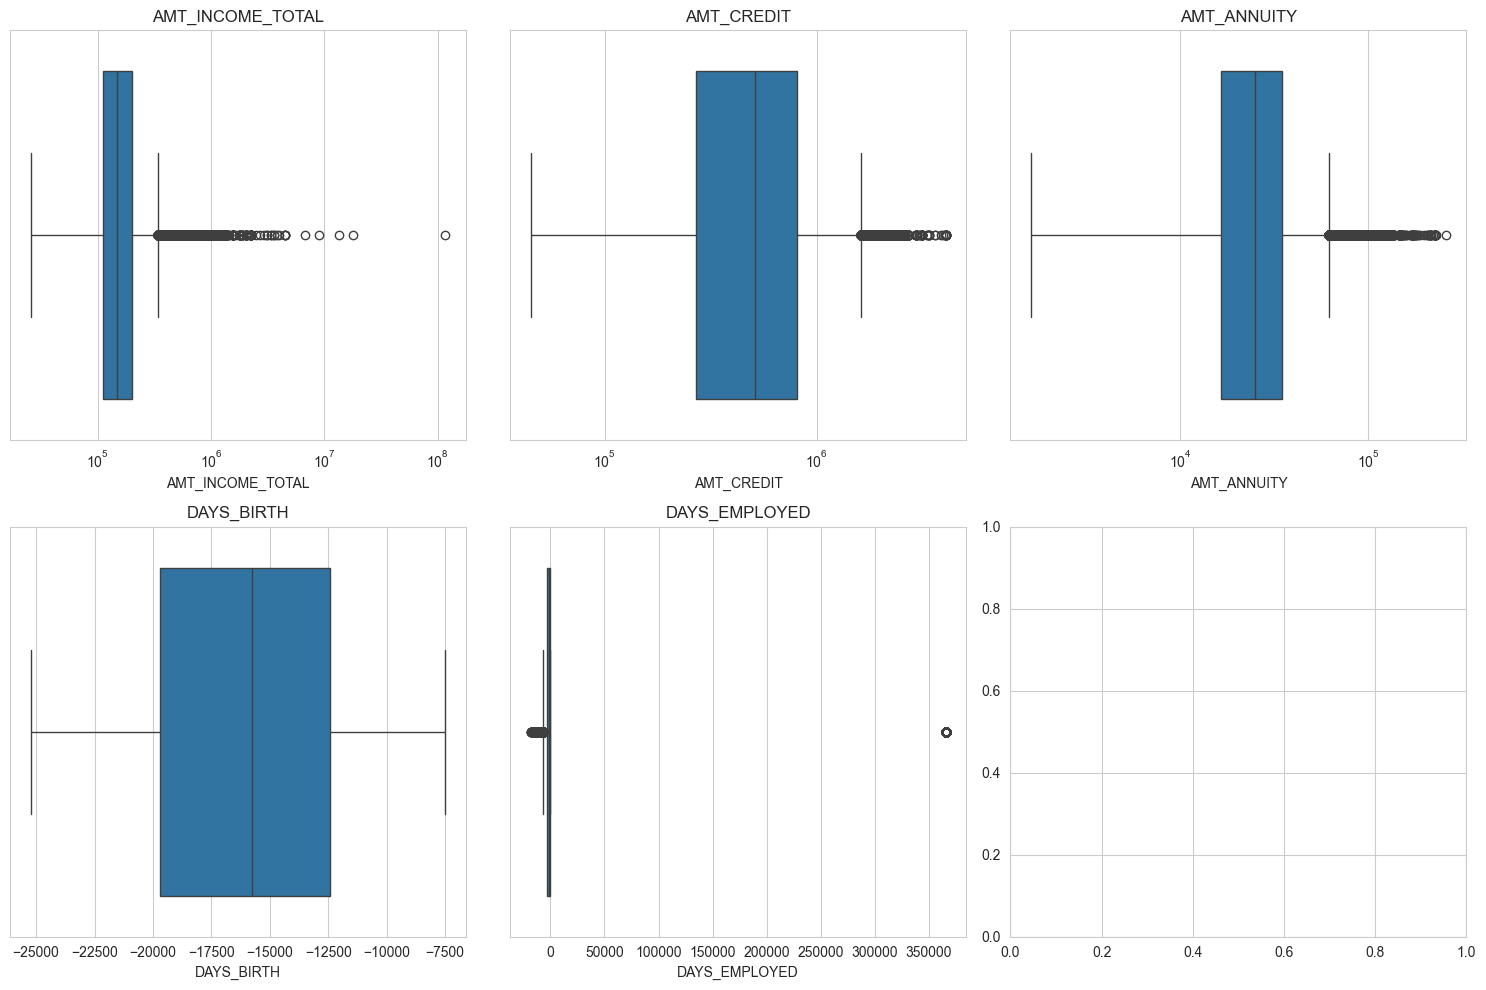

Уникальные значения DAYS_EMPLOYED: [  -637  -1188   -225  -3039  -3038  -1588  -3130   -449 365243  -2019]
Медианное значение DAYS_EMPLOYED: -1213.0


In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

numeric_cols = [col for col in numeric_cols if col not in ['SK_ID_CURR', 'TARGET']]

features_to_plot = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    if i < len(axes):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(col)
        if col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']:
            axes[i].set_xscale('log')
plt.tight_layout()
plt.show()

print("Уникальные значения DAYS_EMPLOYED:", df['DAYS_EMPLOYED'].unique()[:10])
print("Медианное значение DAYS_EMPLOYED:", df['DAYS_EMPLOYED'].median())

Корреляция признаков с целевой переменной

Корреляция с TARGET (топ-10 положительных и топ-10 отрицательных):
TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


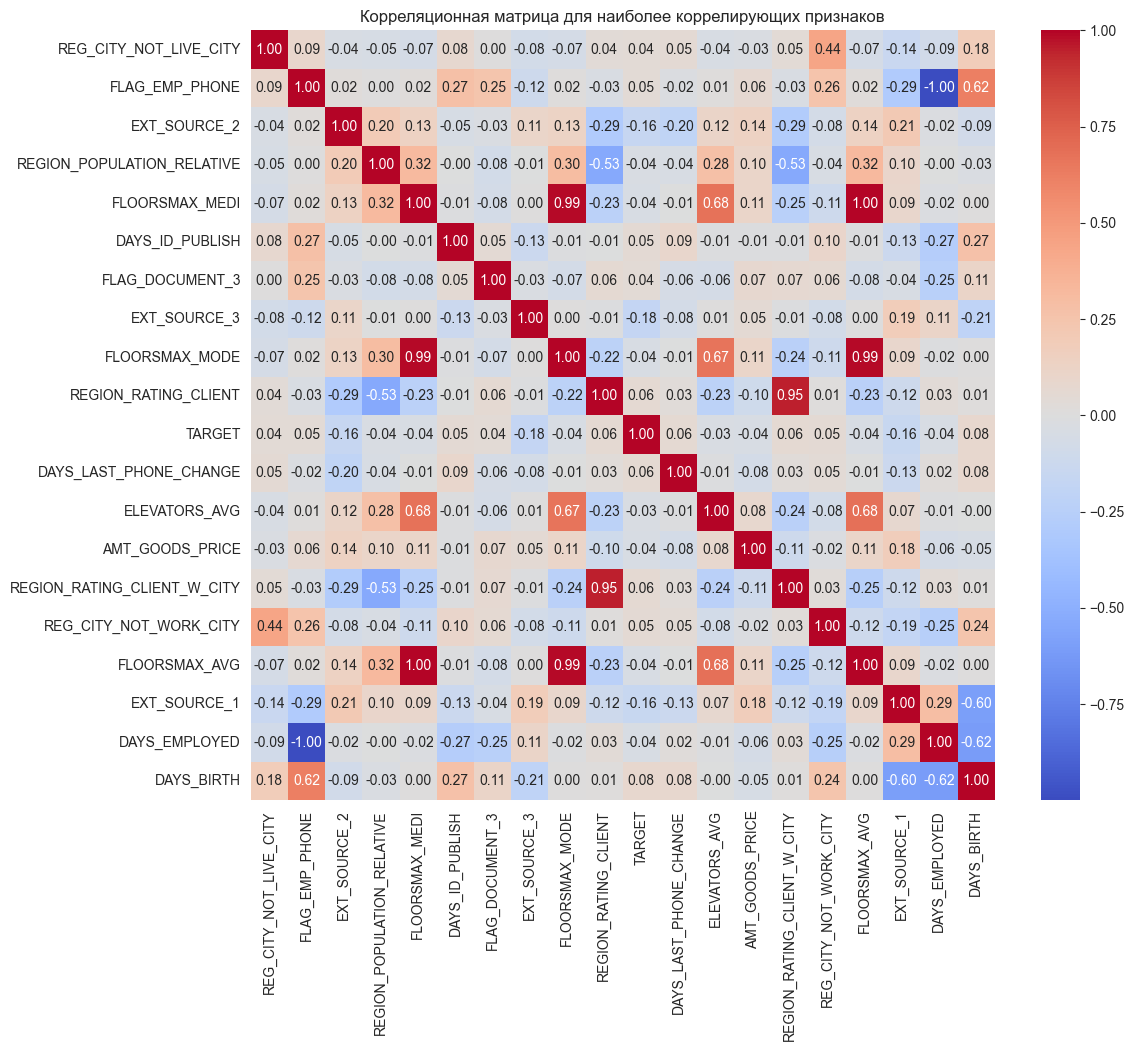

In [13]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['TARGET'].sort_values(ascending=False)
print("Корреляция с TARGET (топ-10 положительных и топ-10 отрицательных):")
print(correlations.head(10))
print(correlations.tail(10))

top_corr = correlations.head(10).index.tolist() + correlations.tail(10).index.tolist()
top_corr = list(set(top_corr))
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица для наиболее коррелирующих признаков')
plt.show()

Анализ категориальных признаков

Категориальные признаки: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR:
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY:
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE:
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Name: count, dtype: int64

NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 158774
Commercial 

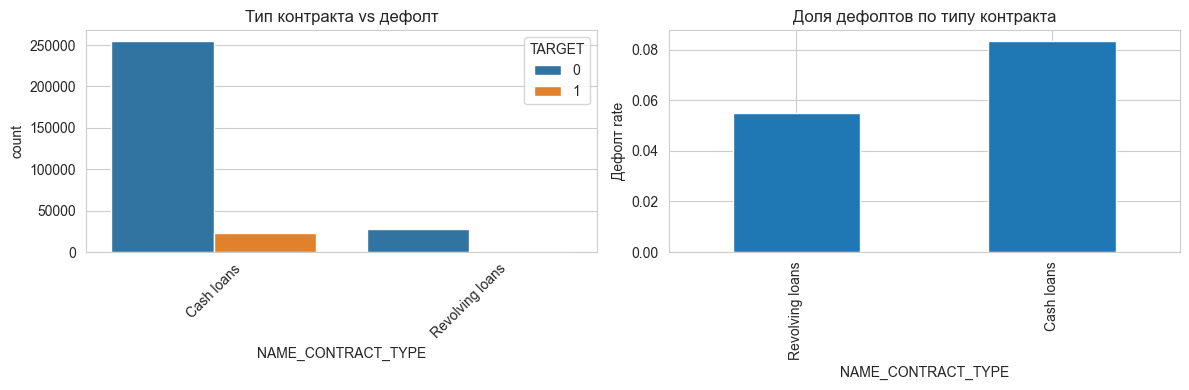

In [14]:
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Категориальные признаки: {list(cat_cols)}")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

# Визуализация влияния категориального признака
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='NAME_CONTRACT_TYPE', hue='TARGET', data=df, ax=axes[0])
axes[0].set_title('Тип контракта vs дефолт')
axes[0].tick_params(axis='x', rotation=45)

default_rate = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().sort_values()
default_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title('Доля дефолтов по типу контракта')
axes[1].set_ylabel('Дефолт rate')
plt.tight_layout()
plt.show()

Распределение числовых признаков

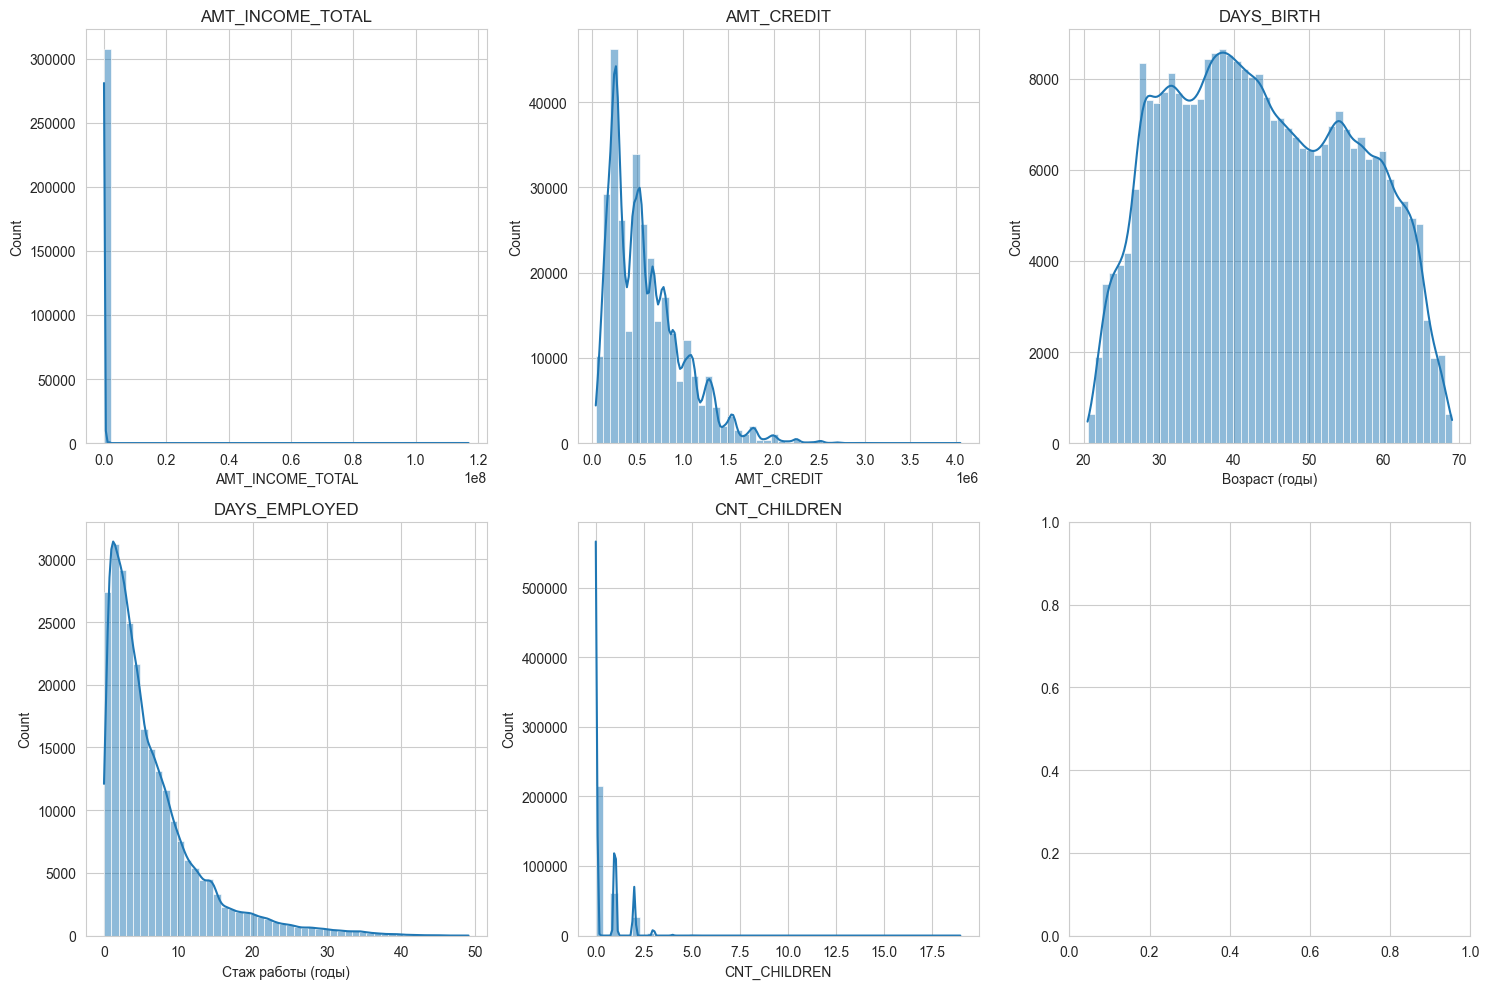

In [15]:
important_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(important_features):
    if i < len(axes):
        if col == 'DAYS_BIRTH':
            data = -df[col] / 365
            xlabel = 'Возраст (годы)'
        elif col == 'DAYS_EMPLOYED':
            data = df[df[col] < 300000][col] / -365
            xlabel = 'Стаж работы (годы)'
        else:
            data = df[col]
            xlabel = col
        
        sns.histplot(data, bins=50, kde=True, ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel(xlabel)
plt.tight_layout()
plt.show()
